## Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import ssl
from collections import Counter
from wordcloud import WordCloud


import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm.notebook import tqdm
from transformers import pipeline
from sklearn.decomposition import NMF


# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from scripts.nlp_preparation import modular_nlp_pipeline
from scripts.ngram import get_top_ngrams
from scripts.extract_noun import extract_nouns
from scripts.theme_assigner import assign_theme


import warnings, re, os, json
warnings.filterwarnings('ignore')

## Download necessary NLTK components

In [ ]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger', 'punkt_tab', 'wordnet', 'averaged_perceptron_tagger_eng']:
    nltk.download(res, quiet=True)

In [2]:
sia = SentimentIntensityAnalyzer()

## Theme for visualization

In [3]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

## LOAD DATA

In [4]:
# Combine all three cleaned datasets
cbe = pd.read_csv('../data/processed/cbe_reviews_clean.csv')
boa = pd.read_csv('../data/processed/boa_reviews_clean.csv')
dashen = pd.read_csv('../data/processed/dashen_reviews_clean.csv')

df = pd.concat([cbe, boa, dashen], ignore_index=True)

print(df.shape)
df.head()

(1500, 5)


,review,rating,date,bank,source
0,good,5,2026-05-12,Commercial Bank of Ethiopia,Google Play
1,cbe,1,2026-05-12,Commercial Bank of Ethiopia,Google Play
2,Good to use,5,2026-05-12,Commercial Bank of Ethiopia,Google Play
3,Cbe,4,2026-05-11,Commercial Bank of Ethiopia,Google Play
4,best and secured,5,2026-05-11,Commercial Bank of Ethiopia,Google Play


## NLP preparation

In [5]:
df['clean_text'] = df['review'].apply(modular_nlp_pipeline)

# Drop invalid/too short reviews
df_clean = df[df['clean_text'].str.len() > 2].copy()
print(f"Final cleaned dataset size: {len(df_clean)}")

Final cleaned dataset size: 1392


## Visualizing Distributions

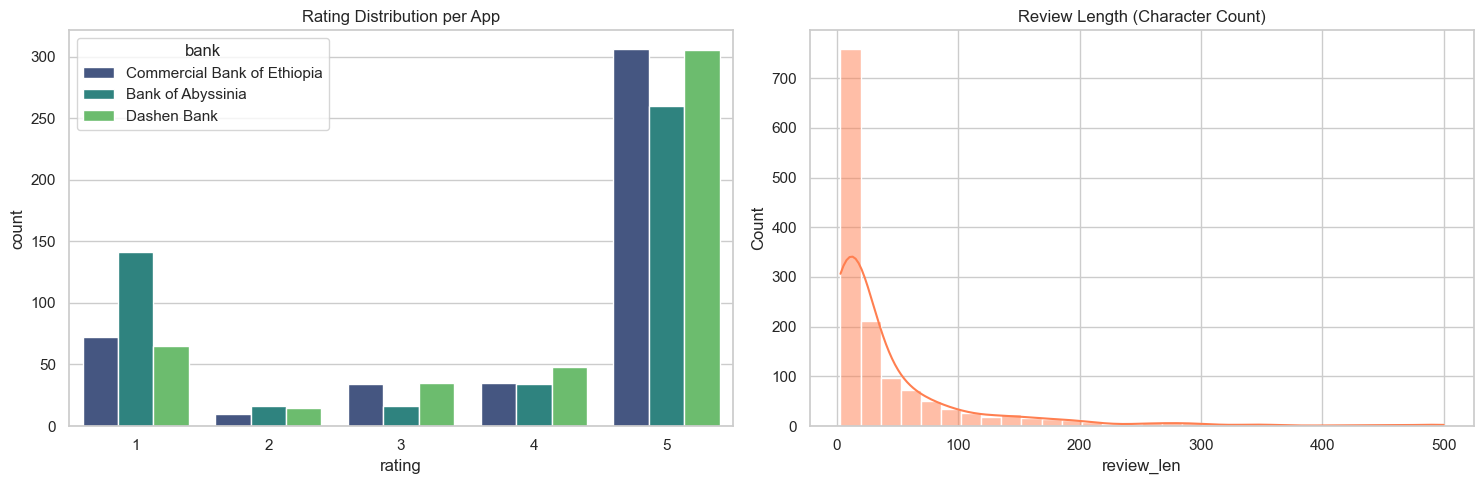

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df_clean, x='rating', hue='bank', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df_clean['review_len'] = df_clean['review'].str.len()
sns.histplot(df_clean['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

## Keyword Extraction

Top 12 Words (Frequency)
['app' 'bank' 'banking' 'best' 'good' 'like' 'mobile' 'nice' 'time'
 'update' 'use' 'work']
[490 121  63 143 332  55  62 106  64  63  73  75]
Top 12 Words (TF-IDF Weight)
['app' 'bank' 'banking' 'best' 'good' 'like' 'mobile' 'nice' 'time'
 'update' 'use' 'work']
[283.32476874  81.6377554   39.34619681 116.77455905 290.3754026
  44.54990851  37.05410748  95.13448267  42.70187721  46.44554077
  53.2471557   56.91448389]


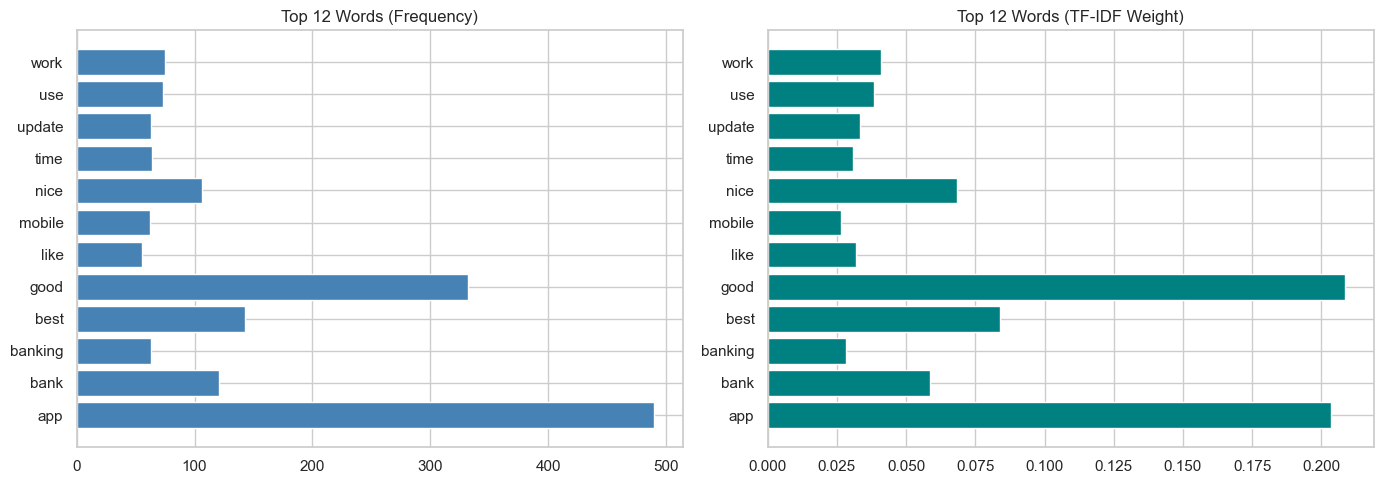

In [7]:
# Frequency (BoW) vs TF-IDF
tfidf_vec = TfidfVectorizer(max_features=12, stop_words='english')
X_tfidf = tfidf_vec.fit_transform(df_clean['clean_text'])

cv_vec = CountVectorizer(max_features=12, stop_words='english')
X_cv = cv_vec.fit_transform(df_clean['clean_text'])

print('Top 12 Words (Frequency)')
print(cv_vec.get_feature_names_out())
print(X_cv.toarray().sum(axis=0))

print('Top 12 Words (TF-IDF Weight)')
print(tfidf_vec.get_feature_names_out())
print(X_tfidf.toarray().sum(axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(cv_vec.get_feature_names_out(), X_cv.toarray().sum(axis=0), color='steelblue')
axes[0].set_title('Top 12 Words (Frequency)')

axes[1].barh(tfidf_vec.get_feature_names_out(), X_tfidf.toarray().mean(axis=0), color='teal')
axes[1].set_title('Top 12 Words (TF-IDF Weight)')

plt.tight_layout()
plt.show()

## N-gram Analysis (Context Discovery)

             ngram  count
60        good app     49
38        best app     44
70  mobile banking     37
71        nice app     35
34     banking app     23
10        app ever     22
46     dashen bank     22
48        easy use     20
69      mobile app     13
51      every time     12
                   ngram  count
52    mobile banking app     12
61        one step ahead      8
2        always one step      7
16      banking app ever      6
20   best mobile banking      6
90  worst mobile banking      6
74        take long time      5
88        worst app ever      5
18         best app ever      5
6          app ever seen      4


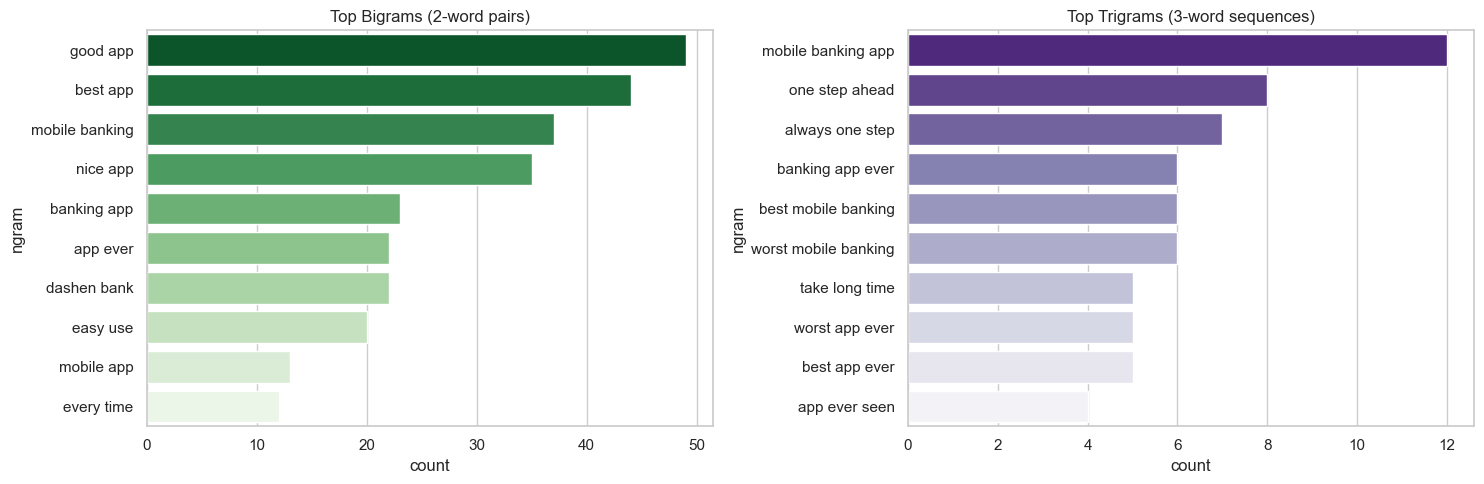

In [8]:
bi = get_top_ngrams(df_clean['clean_text'], 2)
tri = get_top_ngrams(df_clean['clean_text'], 3)

print(bi)
print(tri)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top Bigrams (2-word pairs)')
sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top Trigrams (3-word sequences)')
plt.tight_layout(); plt.show()

## POS Tagging & Noun Extraction

[('app', 446), ('bank', 109), ('banking', 58), ('time', 48), ('application', 46), ('service', 35), ('update', 33), ('boa', 33), ('nice', 31), ('please', 30), ('account', 30), ('cbe', 27)]


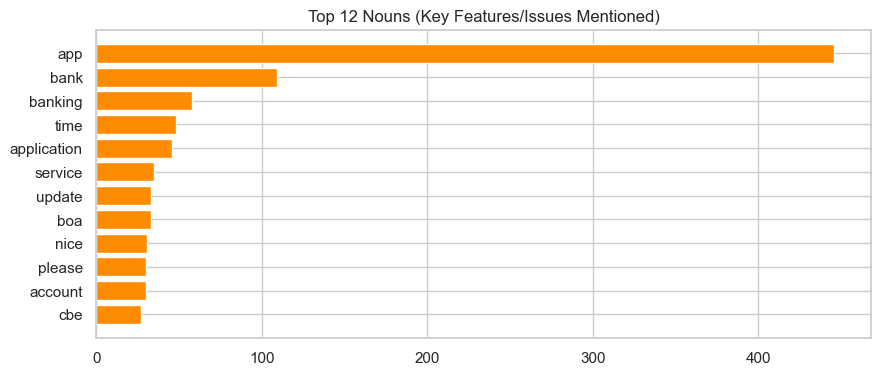

In [9]:
df_clean['nouns'] = df_clean['review'].apply(extract_nouns)
all_nouns = [n for ns in df_clean['nouns'] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)
print(noun_counts)

plt.figure(figsize=(10, 4))
plt.barh([x[0] for x in noun_counts][::-1], [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns (Key Features/Issues Mentioned)')
plt.show()

## Word Cloud Visualization

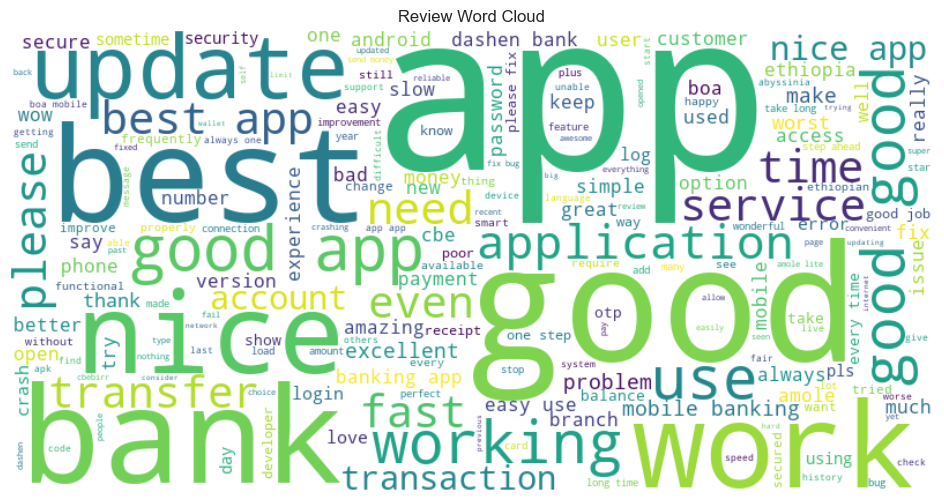

In [10]:
text_combined = " ".join(df_clean['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

## Group Related Keywords Into Themes

### Create Theme Dictionary

In [ ]:
theme_dict = {
    
    # LOGIN / ACCESS
    'Account Access Issues': [
        'login',
        'otp',
        'password',
        'signin',
        'verification',
        'access',
        'account',
        'locked',
        'reset',
        'authenticate',
        'error',
        'open'
    ],

    
    # PERFORMANCE / RELIABILITY
    'Transaction Performance': [
        'slow',
        'loading',
        'transfer',
        'network',
        'crash',
        'failed',
        'working',
        'problem',
        'lag',
        'freeze',
        'stuck',
        'timeout',
        'delay',
        'transaction',
        'fast',
        'work',
        'time'
    ],

    # UI / USER EXPERIENCE
    'UI & User Experience': [
        'ui',
        'design',
        'interface',
        'easy',
        'simple',
        'smooth',
        'friendly',
        'experience',
        'navigation',
        'mobile banking'
    ],

    # CUSTOMER SUPPORT
    'Customer Support': [
        'support',
        'service',
        'help',
        'response',
        'call',
        'branch',
        'agent',
        'customer'
    ],

    # FEATURE REQUESTS
    'Feature Requests': [
        'fingerprint',
        'feature',
        'notification',
        'biometric',
        'dark mode',
        'option',
        'update',
        'version',
        'new'
    ],

    # GENERAL POSITIVE FEEDBACK
    'General Satisfaction': [
        'good',
        'best',
        'nice',
        'excellent',
        'amazing',
        'great',
        'love',
        'perfect',
        'wonderful',
        'wow',
        'better',
        'thanks',
        'fast',
        'fantastic',
        'happy',
        'awesome '
    ],

    # GENERAL NEGATIVE FEEDBACK
    'General Dissatisfaction': [
        'bad',
        'worst'
    ]
}

### Assign Themes to Reviews

In [ ]:
# Apply theme classification
df_clean['theme'] = df_clean['clean_text'].apply(assign_theme, args=(theme_dict, ))

df_clean[['bank', 'clean_text', 'theme']].head()

,bank,clean_text,theme
0,Commercial Bank of Ethiopia,good,General Satisfaction
1,Commercial Bank of Ethiopia,cbe,Other
2,Commercial Bank of Ethiopia,good use,General Satisfaction
3,Commercial Bank of Ethiopia,cbe,Other
4,Commercial Bank of Ethiopia,best secured,General Satisfaction


### Count Themes per bank

In [ ]:
# THEME COUNTS PER BANK
bank_theme_counts = (
    df_clean.groupby(['bank', 'theme'])
            .size()
            .reset_index(name='count')
)

bank_theme_counts.head()

,bank,theme,count
0,Bank of Abyssinia,Account Access Issues,39
1,Bank of Abyssinia,Customer Support,15
2,Bank of Abyssinia,Feature Requests,5
3,Bank of Abyssinia,General Dissatisfaction,13
4,Bank of Abyssinia,General Satisfaction,181


### Percentage Distribution Per Bank

In [14]:
bank_theme_pct = (
    df_clean.groupby(['bank', 'theme'])
            .size()
            .reset_index(name='count')
)

# Calculate percentages within each bank
bank_theme_pct['percentage'] = (
    bank_theme_pct.groupby('bank')['count']
                  .transform(lambda x: 100 * x / x.sum())
)

# Round nicely
bank_theme_pct['percentage'] = (
    bank_theme_pct['percentage']
    .round(2)
)

# Top 5 themes per bank
top_pct = (
    bank_theme_pct
    .sort_values(
        ['bank', 'percentage'],
        ascending=[True, False]
    )
    .groupby('bank')
    .head(5)
)

print(top_pct)

                           bank                    theme  count  percentage
4             Bank of Abyssinia     General Satisfaction    181       38.76
5             Bank of Abyssinia                    Other    103       22.06
6             Bank of Abyssinia  Transaction Performance     96       20.56
0             Bank of Abyssinia    Account Access Issues     39        8.35
1             Bank of Abyssinia         Customer Support     15        3.21
12  Commercial Bank of Ethiopia     General Satisfaction    205       44.86
13  Commercial Bank of Ethiopia                    Other     88       19.26
14  Commercial Bank of Ethiopia  Transaction Performance     86       18.82
8   Commercial Bank of Ethiopia    Account Access Issues     23        5.03
15  Commercial Bank of Ethiopia     UI & User Experience     23        5.03
20                  Dashen Bank     General Satisfaction    202       43.16
21                  Dashen Bank                    Other     94       20.09
22          

### VISUALIZE TOP THEMES PER BANK

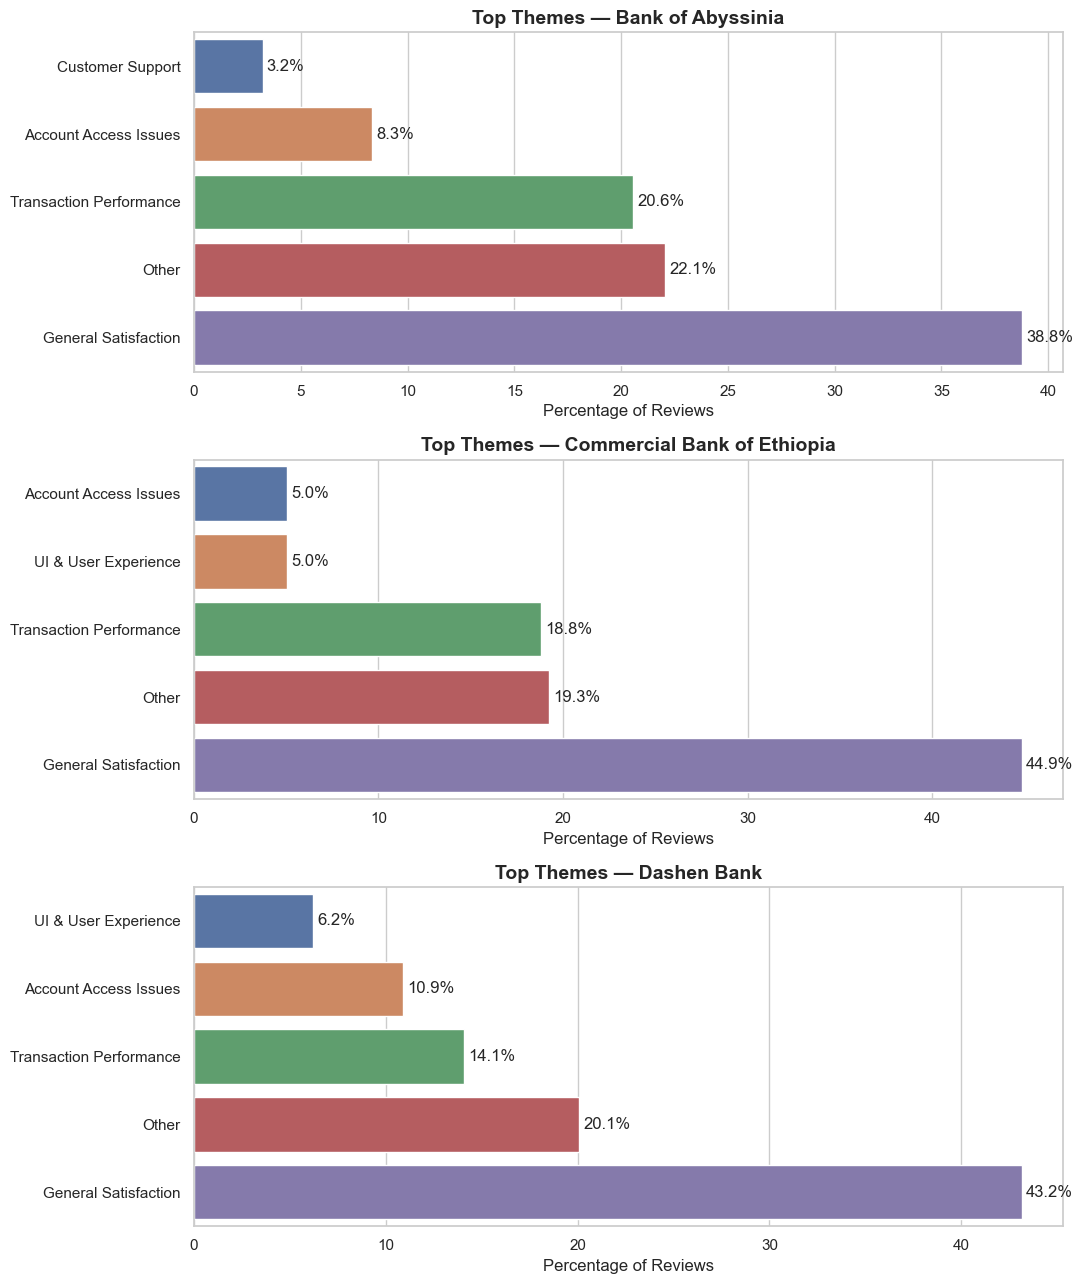

In [15]:
banks = top_pct['bank'].unique()

fig, axes = plt.subplots(
    len(banks),
    1,
    figsize=(11, 13)
)

for ax, bank in zip(axes, banks):

    data = (
        top_pct[top_pct['bank'] == bank]
        .sort_values('percentage', ascending=True)
    )

    sns.barplot(
        data=data,
        x='percentage',
        y='theme',
        hue='theme',
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(
        f'Top Themes — {bank}',
        fontsize=14,
        weight='bold'
    )

    ax.set_xlabel('Percentage of Reviews')
    ax.set_ylabel('')

    # Add percentage labels
    for container in ax.containers:
        labels = [
            f'{v.get_width():.1f}%'
            for v in container
        ]
        ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

### Inspect the "OTHER" reviews

In [16]:
other_reviews = df_clean[
    df_clean['theme'] == 'Other'
]['clean_text']

print(f"Other reviews count: {len(other_reviews)}")

other_vec = CountVectorizer(
    stop_words='english',
    max_features=40
)

X_other = other_vec.fit_transform(other_reviews)

other_counts = pd.DataFrame({
    'word': other_vec.get_feature_names_out(),
    'count': X_other.toarray().sum(axis=0)
})

other_counts = other_counts.sort_values(
    'count',
    ascending=False
)

print(other_counts)

Other reviews count: 285
           word  count
3           app     64
7          bank     24
19         like     17
9           boa     13
10          cbe     11
13       dashen      8
36          use      7
35        thank      6
33         step      5
32        smart      5
20       mobile      5
8       banking      5
0         ahead      5
4   application      5
34        super      4
28       really      4
23       number      4
38          waw      4
1          alot      3
2         amole      3
39          way      3
21         need      3
15  exceptional      3
11       choice      3
29     reliable      3
12        crush      3
17         goof      3
18   itoophiyaa      3
16          fix      3
26         poor      3
14       dashin      3
5       awesome      2
6       balance      2
22          nic      2
31       secure      2
27        proud      2
24      payment      2
30       saying      2
25       people      2
37         used      2


### What the results show:

Most `"Other"` reviews are:

1. low-information reviews,
2. very short praise,
3. or vague opinions.

So instead of forcing every word into a theme, its better to leave it out.


## Thematic Analysis Methodology

The thematic analysis process was designed to transform unstructured mobile banking reviews into business-relevant insight categories that can support product improvement decisions for Ethiopian banks.

The analysis combined multiple Natural Language Processing (NLP) techniques, including keyword extraction, n-gram analysis, and rule-based theme classification.

---

## 1. Text Preprocessing

Before thematic analysis, review text was cleaned and standardized to improve analysis quality.

The preprocessing pipeline included:

* removal of duplicate reviews,
* removal of missing or empty review text,
* whitespace normalization,
* date standardization,
* and rating validation.

Unicode characters, emojis, and Amharic text were preserved to retain original user sentiment and multilingual feedback context.

---

## 2. Keyword Extraction

To identify the most important and recurring terms within reviews, two vectorization approaches were applied:

### Bag-of-Words (CountVectorizer)

CountVectorizer was used to measure raw word frequency across reviews. This helped identify the most commonly mentioned terms in customer feedback.

Examples included:

* app
* banking
* update
* transfer
* service
* login

### TF-IDF (Term Frequency–Inverse Document Frequency)

TF-IDF weighting was used to identify words that were both:

* frequent,
* and contextually informative.

Unlike raw frequency counts, TF-IDF reduces the importance of overly common words and highlights terms more specific to customer concerns or experiences.

This helped identify operationally meaningful keywords such as:

* login error,
* slow transfer,
* mobile banking,
* app crash,
* and update problem.

---

## 3. N-gram Analysis

Bigram and trigram extraction was performed to capture contextual phrases rather than isolated words.

This step was important because many banking-related issues are expressed as multi-word phrases rather than single tokens.

Examples of extracted phrases included:

* good app
* mobile banking
* login error
* slow transfer
* worst app ever
* take long time

N-gram analysis improved interpretation accuracy by revealing recurring complaint patterns and user experience expressions.

---

## 4. Part-of-Speech (POS) Tagging and Noun Extraction

Part-of-Speech tagging was applied to extract nouns and noun phrases from reviews.

Nouns were prioritized because they often represent:

* products,
* features,
* services,
* or operational issues.

Examples included:

* app
* account
* service
* update
* transfer
* banking

This step supported manual theme interpretation and validation.

---

## 5. Theme Construction Logic

Themes were manually constructed by grouping semantically related keywords and phrases into higher-level business categories.

The grouping process was intentionally business-oriented to ensure that extracted insights could directly support product and customer experience decisions.

The final themes included:

| Theme                   | Purpose                                                        |
| ----------------------- | -------------------------------------------------------------- |
| Account Access Issues   | Login failures, OTP problems, password/access issues           |
| Transaction Performance | Slow transfers, crashes, delays, failed operations             |
| UI & User Experience    | Interface usability, navigation, and ease of use               |
| Customer Support        | Customer service responsiveness and assistance                 |
| Feature Requests        | Desired enhancements such as biometric login and notifications |
| General Satisfaction    | Generic positive praise and approval                           |
| General Dissatisfaction | Generic negative reactions and criticism                       |

Keywords and phrases were assigned to themes using a rule-based matching approach.

For example:

* “OTP not received” → Account Access Issues
* “transfer takes too long” → Transaction Performance
* “easy to use app” → UI & User Experience

---

## 6. Theme Assignment Strategy

Each review was assigned a dominant theme based on keyword priority matching.

A priority order was used to ensure that operational issues were prioritized over generic praise or criticism.

For example:

```text id="3rk9zx"
"Good app but login problem"
```

was classified as:

```text id="3z1hgh"
Account Access Issues
```

rather than:

```text id="f1hjs8"
General Satisfaction
```

This improved the business relevance of classifications and reduced misleading positive categorization.

---

## 7. Bank-Specific Theme Analysis

After theme assignment, reviews were grouped by bank to identify the dominant themes for:

* Commercial Bank of Ethiopia
* Bank of Abyssinia
* Dashen Bank

Theme frequencies and percentages were calculated separately for each institution to identify:

* recurring complaints,
* common strengths,
* and institution-specific customer experience patterns.

---

## 8. Topic Modeling Support

No topic modeling was used since experiment with NMF revealed that most of the themes identified are only general satisfaction/dissatisfaction ignoring business-oriented problems

## Multi-Model Sentiment Analysis

### Lexicon Comparison
We use **TextBlob** (Polarity & Subjectivity) and **VADER** (Compound Score).
- **Polarity**: [-1, 1] (Negative to Positive)
- **Subjectivity**: [0, 1] (Fact to Opinion)

In [17]:
# Sentiment Application
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(x)['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

def get_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df_clean['sentiment'] = df_clean['vader_compound'].apply(get_label)
print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))

VADER Distribution:
 sentiment
positive    0.64
neutral     0.23
negative    0.13
Name: proportion, dtype: float64


### Sentiment vs. Star Rating

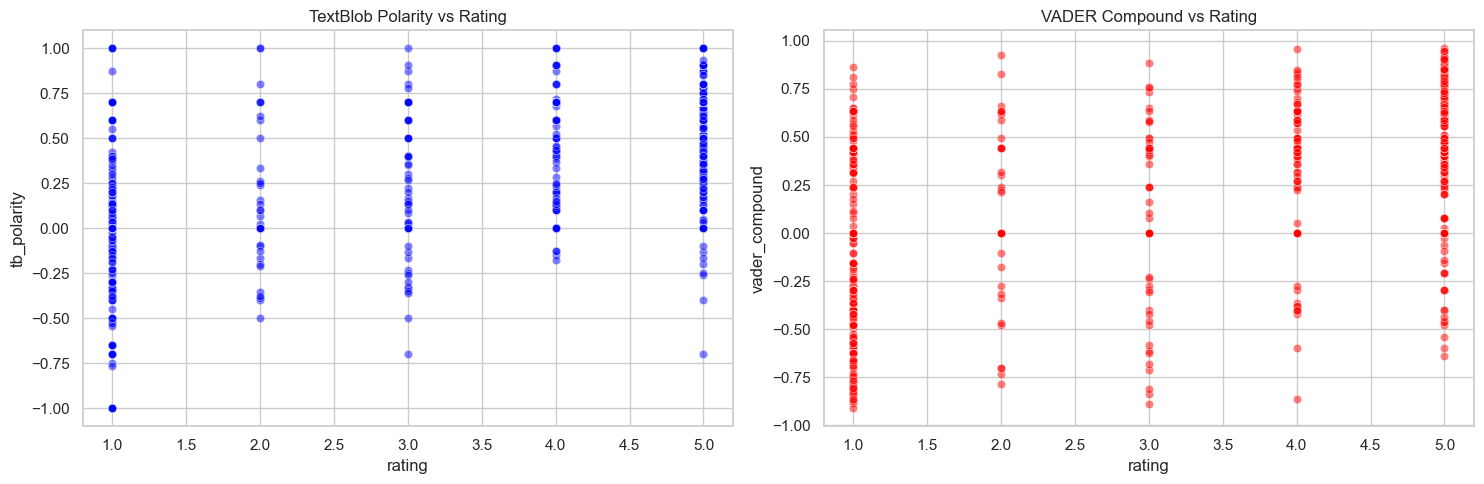

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df_clean, x='rating', y='tb_polarity', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Rating')

# VADER Scatter
sns.scatterplot(data=df_clean, x='rating', y='vader_compound', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Rating')

plt.tight_layout(); plt.show()

### Transformer-based Sentiment

In [19]:
# 1. Initialize and download completely BEFORE starting the loop
sent_model = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english", 
    framework="pt",
    batch_size=16 # Enables pipeline-level batching optimization
)

# 2. Process data in chunks with a responsive progress bar
transformer_results = []
batch_size = 16 

for i in tqdm(range(0, len(df_clean), batch_size), desc="Running Transformer Sentiment"):
    batch = df_clean['review'].iloc[i:i + batch_size].tolist()
    preds = sent_model(batch)
    transformer_results.extend(preds)

# 3. Save results to DataFrame
df_clean['transformer_sentiment_label'] = [p['label'] for p in transformer_results]
df_clean['transformer_sentiment_score'] = [
    p['score'] if p['label'] == 'POSITIVE' else -p['score'] 
    for p in transformer_results
]

print("\nTransformer Sentiment Distribution:")
print(df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased-finetuned-sst-2-english/resolve/main/config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000020F48862BA0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: a9ee8b69-9a8d-4251-8e09-0dc9f31cdc0f)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /distilbert-base-uncased-finetuned-sst-2-english/resolve/main/config.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000020F4D733ED0>: Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 8179e75a-bb73-4cfd-b1dd-0d3b2f12ffdc)')' thrown while requesting HEA

Running Transformer Sentiment:   0%|          | 0/87 [00:00<?, ?it/s]


Transformer Sentiment Distribution:
transformer_sentiment_label
POSITIVE    0.65
NEGATIVE    0.35
Name: proportion, dtype: float64


## Sentiment Model Comparison: VADER, TextBlob, and Transformer

### Visualizing Sentiment Score Correlation

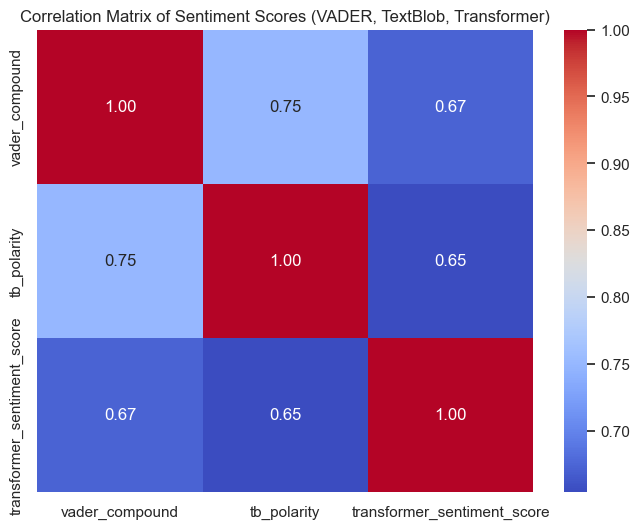

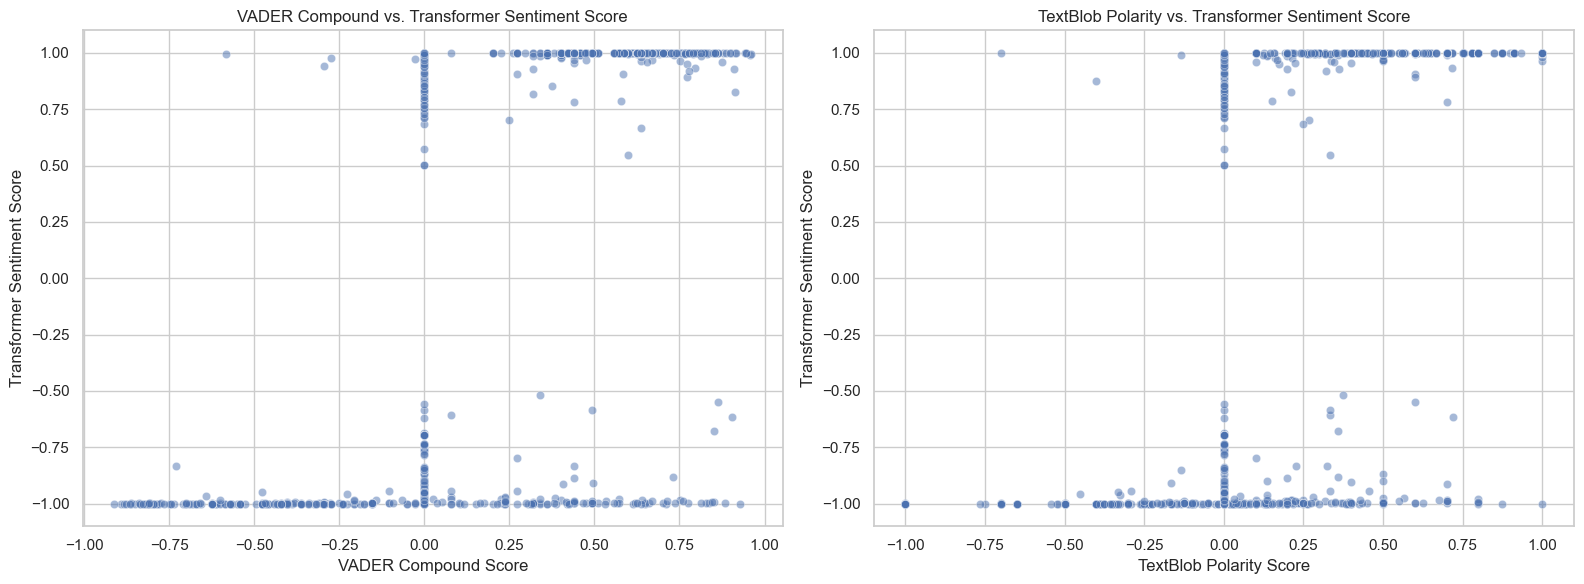

In [20]:
# Ensure transformer_sentiment_score is available
if 'transformer_sentiment_score' not in df_clean.columns:
    print("Transformer sentiment scores not available for comparison.")
else:
    # Create a DataFrame for correlation
    sentiment_scores = df_clean[['vader_compound', 'tb_polarity', 'transformer_sentiment_score']]

    # Calculate the correlation matrix
    correlation_matrix = sentiment_scores.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Sentiment Scores (VADER, TextBlob, Transformer)')
    plt.show()

    # Plotting scatter plots for pairwise comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=df_clean, x='vader_compound', y='transformer_sentiment_score', alpha=0.5, ax=axes[0])
    axes[0].set_title('VADER Compound vs. Transformer Sentiment Score')
    axes[0].set_xlabel('VADER Compound Score')
    axes[0].set_ylabel('Transformer Sentiment Score')

    sns.scatterplot(data=df_clean, x='tb_polarity', y='transformer_sentiment_score', alpha=0.5, ax=axes[1])
    axes[1].set_title('TextBlob Polarity vs. Transformer Sentiment Score')
    axes[1].set_xlabel('TextBlob Polarity Score')
    axes[1].set_ylabel('Transformer Sentiment Score')

    plt.tight_layout()
    plt.show()

### Comparing Sentiment Distributions

In [21]:
if 'transformer_sentiment_label' not in df_clean.columns:
    print("Transformer sentiment labels not available for comparison.")
else:
    print("\n--- Sentiment Label Distributions ---")
    print("VADER Distribution:\n", df_clean['sentiment'].value_counts(normalize=True).round(2))
    print("\nTextBlob Polarity Distribution (thresholded at +/-0.05):\n")
    def get_tb_label(s):
        return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')
    print(df_clean['tb_polarity'].apply(get_tb_label).value_counts(normalize=True).round(2))
    print("\nTransformer Distribution:\n", df_clean['transformer_sentiment_label'].value_counts(normalize=True).round(2))


--- Sentiment Label Distributions ---
VADER Distribution:
 sentiment
positive    0.64
neutral     0.23
negative    0.13
Name: proportion, dtype: float64

TextBlob Polarity Distribution (thresholded at +/-0.05):

tb_polarity
positive    0.64
neutral     0.27
negative    0.09
Name: proportion, dtype: float64

Transformer Distribution:
 transformer_sentiment_label
POSITIVE    0.65
NEGATIVE    0.35
Name: proportion, dtype: float64


### Aggregating Sentiment Scores by App and Star Rating

In [22]:
# Aggregate VADER sentiment scores by bank and star rating
vader_agg_sentiment = df_clean.groupby(['bank', 'rating'])['vader_compound'].mean().unstack()
display(vader_agg_sentiment)

# Aggregate TextBlob polarity scores by bank and star rating
tb_agg_sentiment = df_clean.groupby(['bank', 'rating'])['tb_polarity'].mean().unstack()
display(tb_agg_sentiment)

# Aggregate Transformer sentiment scores by bank and star rating
transformer_agg_sentiment = df_clean.groupby(['bank', 'rating'])['transformer_sentiment_score'].mean().unstack()
display(transformer_agg_sentiment)

rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.172288,0.055212,0.130938,0.328109,0.375285
Commercial Bank of Ethiopia,-0.022315,0.242900,-0.049276,0.224769,0.412555
Dashen Bank,-0.066351,0.045293,0.204209,0.407398,0.437346


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.105071,0.112909,0.243804,0.422623,0.498437
Commercial Bank of Ethiopia,0.020516,0.272652,0.171034,0.345911,0.533863
Dashen Bank,0.044083,0.056738,0.209147,0.374819,0.494522


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.827311,-0.563670,-0.258675,0.121218,0.698481
Commercial Bank of Ethiopia,-0.571238,-0.820341,-0.346410,0.039527,0.781356
Dashen Bank,-0.557909,-0.574511,0.073351,0.508065,0.690436


### Visualize VADER sentiment by app and rating

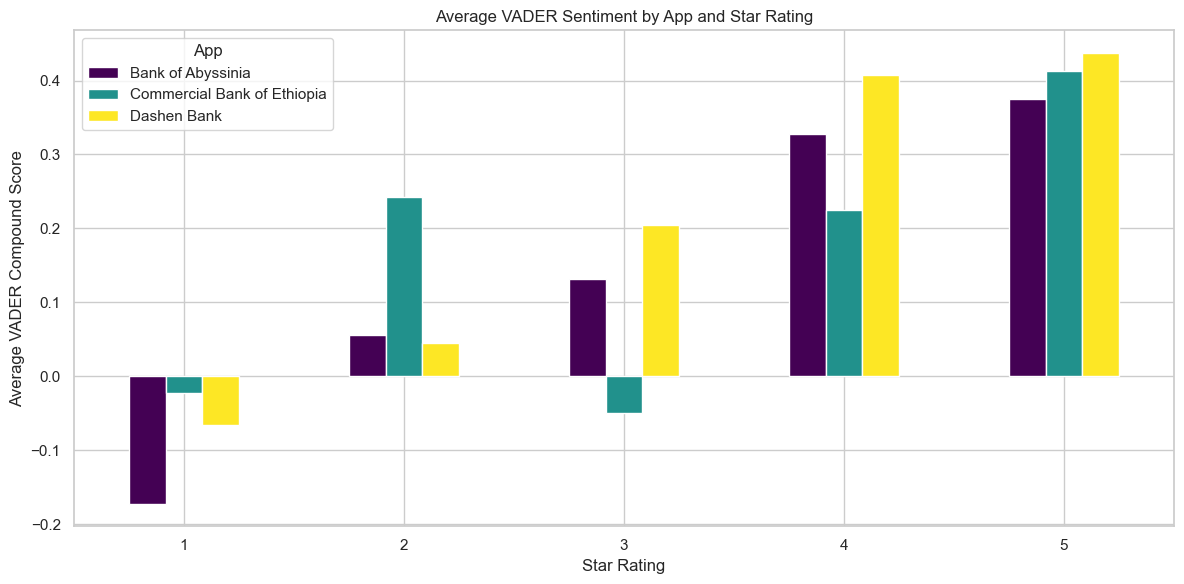

In [23]:
vader_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Average VADER Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Compound Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

### Visualize Transformer sentiment by app and rating

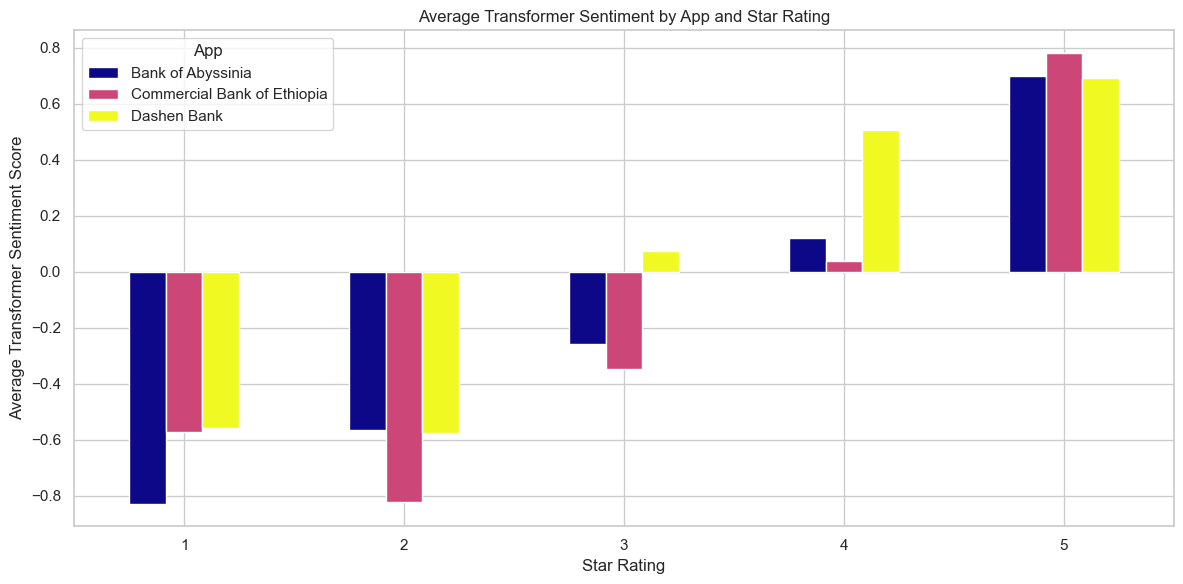

In [25]:
transformer_agg_sentiment.T.plot(kind='bar', figsize=(12, 6), colormap='plasma')
plt.title('Average Transformer Sentiment by App and Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Transformer Sentiment Score')
plt.xticks(rotation=0)
plt.legend(title='App')
plt.tight_layout()
plt.show()

### CREATE FINAL ANALYTICS DATASET

In [28]:
final_df = df_clean.copy()

# Create review_id from dataframe index
final_df = final_df.reset_index(drop=True)

final_df['review_id'] = (
    final_df.index + 1
)

# Rename required columns
final_df = final_df.rename(columns={

    'clean_text': 'review_text',

    'transformer_sentiment_label':
        'sentiment_label',

    'transformer_sentiment_score':
        'sentiment_score',

    'theme':
        'identified_theme'
})

# Drop unnecessary intermediate columns
cols_to_drop = [

    'review',

    'review_len',

    'nouns',

    'vader_compound',

    'tb_polarity',

    'tb_subjectivity',

    'sentiment',

    'dominant_topic'
]

# Drop only if column exists
final_df = final_df.drop(
    columns=[c for c in cols_to_drop
             if c in final_df.columns]
)

# Reorder columns
final_df = final_df[[
    
    'review_id',

    'review_text',

    'rating',

    'date',

    'bank',

    'source',

    'sentiment_label',

    'sentiment_score',

    'identified_theme'
]]

# Preview
final_df.head()

,review_id,review_text,rating,date,bank,source,sentiment_label,sentiment_score,identified_theme
0,1,good,5,2026-05-12,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.999816,General Satisfaction
1,2,cbe,1,2026-05-12,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.996601,Other
2,3,good use,5,2026-05-12,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.999846,General Satisfaction
3,4,cbe,4,2026-05-11,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.996601,Other
4,5,best secured,5,2026-05-11,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.999819,General Satisfaction


### Save Final CSV

In [30]:
output_path = '../data/processed/final_mobile_reviews.csv'

final_df.to_csv(
    output_path,
    index=False
)

print(f"Saved to: {output_path}")

Saved to: ../data/processed/final_mobile_reviews.csv


## Sentiment Analysis Tool Selection Rationale

Three sentiment analysis approaches were evaluated during the analysis process:

1. VADER
2. TextBlob
3. distilbert-base-uncased-finetuned-sst-2-english

The objective of comparing multiple approaches was to determine which model produced the most reliable and business-relevant sentiment classifications for Ethiopian mobile banking reviews.

---

## 1. VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lightweight lexicon and rule-based sentiment analysis tool optimized for short social-media-style text.

Advantages:

* Fast and computationally efficient
* Handles punctuation and emojis reasonably well
* Produces interpretable compound sentiment scores

However, VADER relies on predefined sentiment dictionaries and does not fully capture contextual meaning. It may struggle with:

* banking-specific terminology,
* mixed sentiment reviews,
* multilingual text,
* and nuanced complaints.

VADER produced a large proportion of positive reviews and relatively fewer negative classifications, suggesting that it may under-detect operational frustration in customer feedback.

---

## 2. TextBlob

TextBlob provides polarity and subjectivity scores using a lexicon-based approach.

Advantages:

* Simple to implement
* Easy to interpret
* Useful for basic polarity estimation

However, similar to VADER, TextBlob lacks contextual language understanding and performed similarly by heavily skewing toward positive and neutral classifications.

TextBlob also showed limited sensitivity to nuanced complaints and transactional frustration patterns commonly found in mobile banking reviews.

---

## 3. DistilBERT Transformer Model

The transformer-based model:

```text id="u9t0w2"
distilbert-base-uncased-finetuned-sst-2-english
```

was ultimately selected as the primary sentiment analysis model.

This model is a distilled version of BERT fine-tuned on the SST-2 sentiment benchmark dataset.

Advantages:

* Context-aware language understanding
* Better handling of nuanced sentiment
* Stronger performance on conversational review text
* More effective detection of subtle negative feedback
* Produces confidence scores for predictions

Unlike VADER and TextBlob, the transformer model identified a substantially larger proportion of negative reviews, indicating improved sensitivity to operational complaints such as:

* slow transfers,
* crashes,
* login failures,
* and reliability issues.

This behavior was considered more realistic given the nature of mobile banking user feedback.

---

## Final Tool Selection

The transformer-based DistilBERT model was selected as the primary sentiment classification approach because it provided:

* stronger contextual understanding,
* better complaint detection,
* more balanced sentiment classification,
* and more actionable business insight.

VADER and TextBlob were retained as baseline comparison models to validate consistency and demonstrate methodological rigor.
